## Data loading

### Subtask:
Load the dataset.


**Reasoning**:
Load the dataset and display basic information.



In [82]:
# Last edited: 03-31-2025

import pandas as pd

playerData = pd.read_csv('merged_playerStats.csv')
display(playerData.head())
print(playerData.shape)
print(playerData.dtypes)


,Player,height,weight,college,Year,Pos,Age,G,MP,PER,...,3P%,2P%,eFG%,FT%,TRB,AST,STL,BLK,TOV,PTS
0,Curly Armstrong,180.0,77.0,Indiana University,1950.50,G-F,31.50,50.500000,NaN,NaN,...,NaN,0.290663,0.290663,0.682050,NaN,138.752475,NaN,NaN,NaN,361.683168
1,Cliff Barker,188.0,83.0,University of Kentucky,1951.00,SG,30.00,49.666667,494.000000,NaN,...,NaN,0.305047,0.305047,0.650389,NaN,99.738255,NaN,NaN,NaN,186.087248
2,Leo Barnhorst,193.0,86.0,University of Notre Dame,1952.00,SF,27.00,68.800000,2426.333333,NaN,...,NaN,0.362035,0.362035,0.676922,NaN,223.758721,NaN,NaN,NaN,646.636628
3,Ed Bartels,196.0,88.0,North Carolina State University,1950.25,F,24.25,11.750000,NaN,NaN,...,NaN,0.252489,0.252489,0.547170,NaN,16.255319,NaN,NaN,NaN,62.638298
4,Ralph Beard,178.0,79.0,University of Kentucky,1950.50,G,22.50,63.000000,NaN,NaN,...,NaN,0.365619,0.365619,0.768810,NaN,277.523810,NaN,NaN,NaN,1008.142857


(3921, 26)
Player      object
height     float64
weight     float64
college     object
Year       float64
Pos         object
Age        float64
G          float64
MP         float64
PER        float64
TS%        float64
USG%       float64
WS         float64
BPM        float64
VORP       float64
FG%        float64
3P%        float64
2P%        float64
eFG%       float64
FT%        float64
TRB        float64
AST        float64
STL        float64
BLK        float64
TOV        float64
PTS        float64
dtype: object


## Data exploration

### Subtask:
Explore the dataset to understand the distributions of player physical attributes and performance metrics.


**Reasoning**:
Identify the relevant columns, check for missing values, convert data types, and analyze distributions. Generate descriptive statistics and visualizations. Calculate correlations and visualize them using a heatmap. Summarize findings.



Missing Values:
 height    0
weight    0
Age       0
BPM       0
VORP      0
WS        0
dtype: int64

Missing Value Percentage:
 height    0.0
weight    0.0
Age       0.0
BPM       0.0
VORP      0.0
WS        0.0
dtype: float64

Descriptive Statistics:
             height       weight          Age          BPM         VORP  \
count  3921.000000  3921.000000  3921.000000  3921.000000  3921.000000   
mean    198.704922    94.783219    25.246367    -3.354373     0.198280   
std       9.269761    12.039515     2.629688     4.081125     0.809884   
min     160.000000    60.000000    18.500000   -53.600000    -1.214570   
25%     190.000000    86.000000    23.000000    -4.376560    -0.132487   
50%     198.000000    95.000000    25.000000    -2.879878    -0.017647   
75%     206.000000   102.000000    27.000000    -1.686775     0.154678   
max     231.000000   163.000000    36.666667    26.600000     8.315174   

                WS  
count  3921.000000  
mean      1.685295  
std       2.239

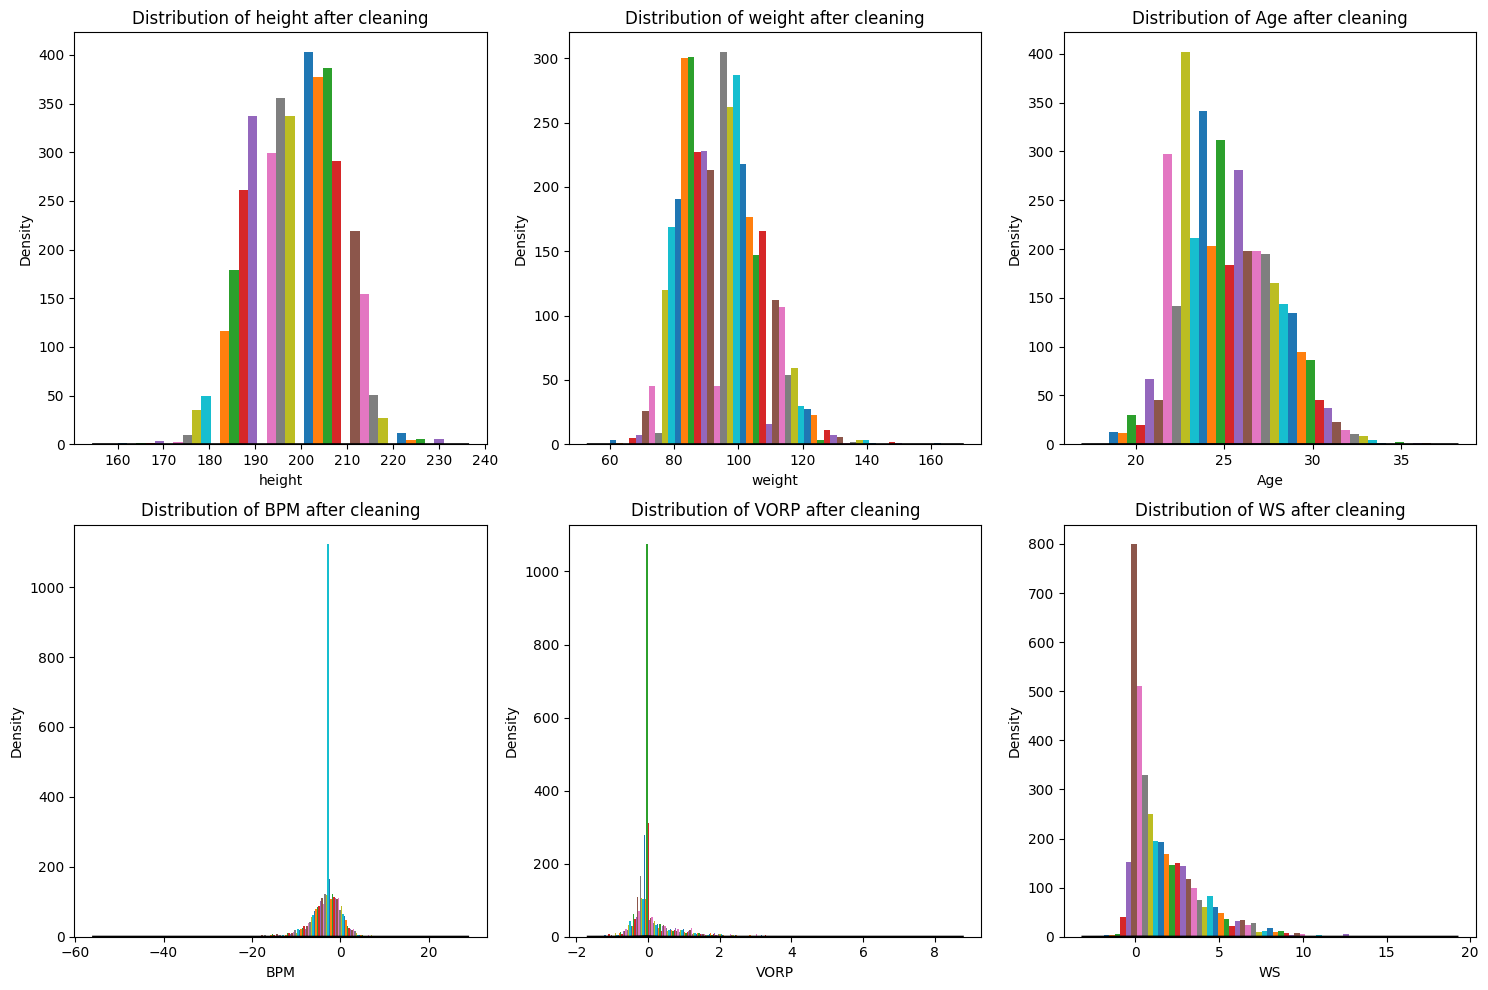


Correlation Matrix:
           height    weight       Age       BPM      VORP        WS
height  1.000000  0.825630 -0.015828  0.004132  0.102916  0.088543
weight  0.825630  1.000000 -0.010623  0.010416  0.086733  0.083974
Age    -0.015828 -0.010623  1.000000  0.275372  0.297502  0.458902
BPM     0.004132  0.010416  0.275372  1.000000  0.512709  0.501665
VORP    0.102916  0.086733  0.297502  0.512709  1.000000  0.741026
WS      0.088543  0.083974  0.458902  0.501665  0.741026  1.000000


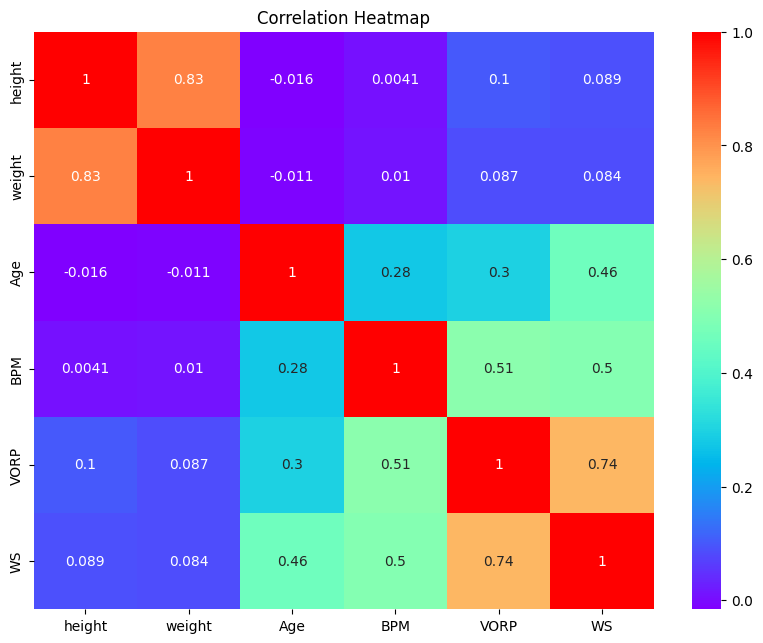


Strongest positive correlation: height  height    1.0
dtype: float64

Strongest negative correlation: height  Age   -0.015828
dtype: float64

Summary:
  Missing values: height    0
weight    0
Age       0
BPM       0
VORP      0
WS        0
dtype: int64
  Strongest positive correlation: height  height    1.0
dtype: float64
  Strongest negative correlation: height  Age   -0.015828
dtype: float64


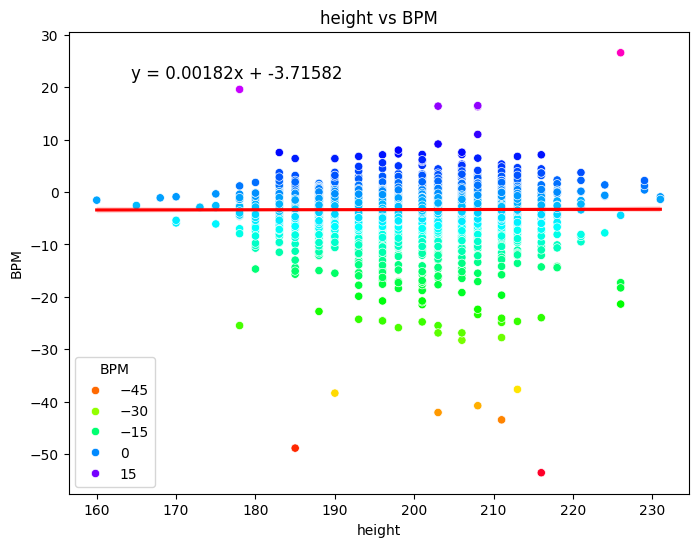

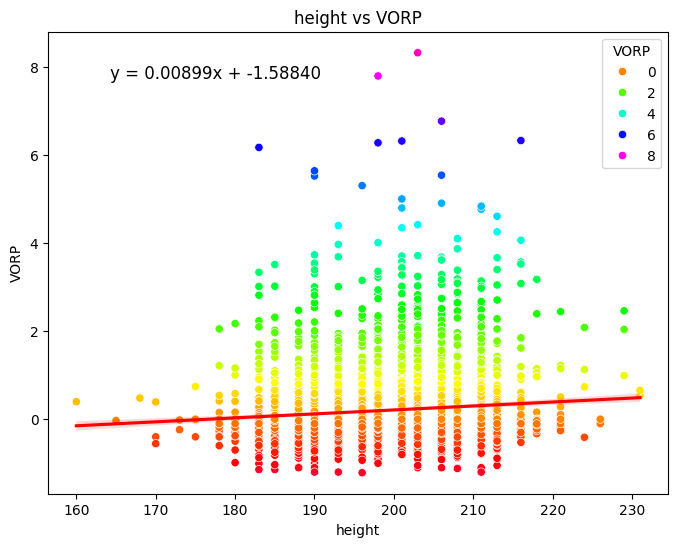

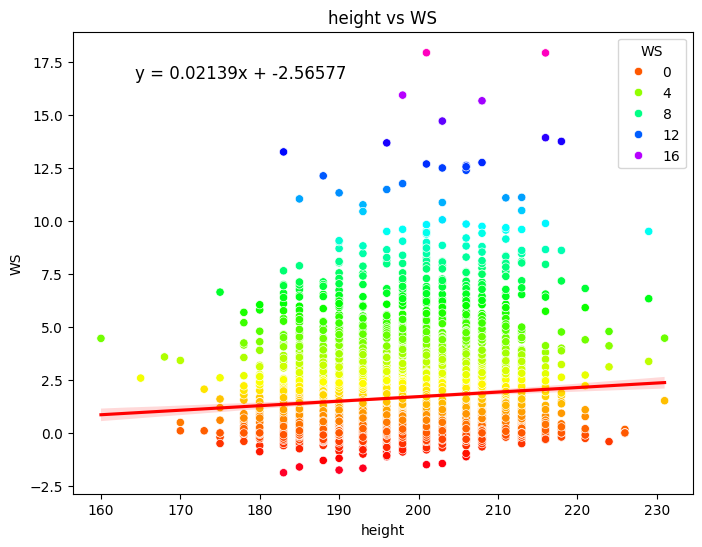

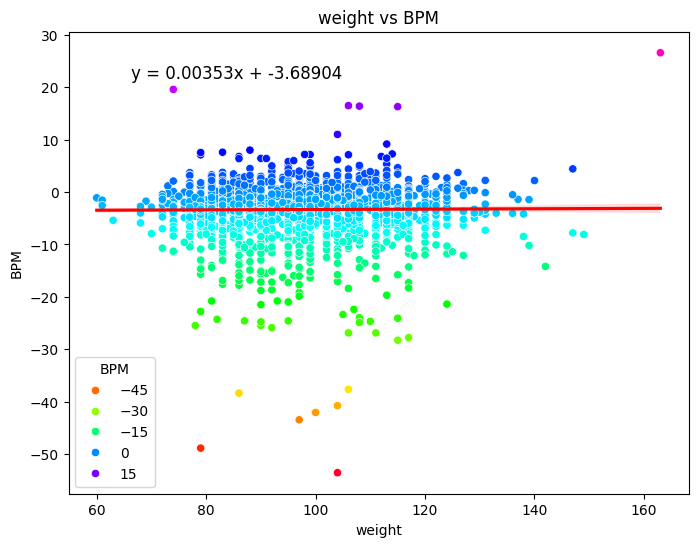

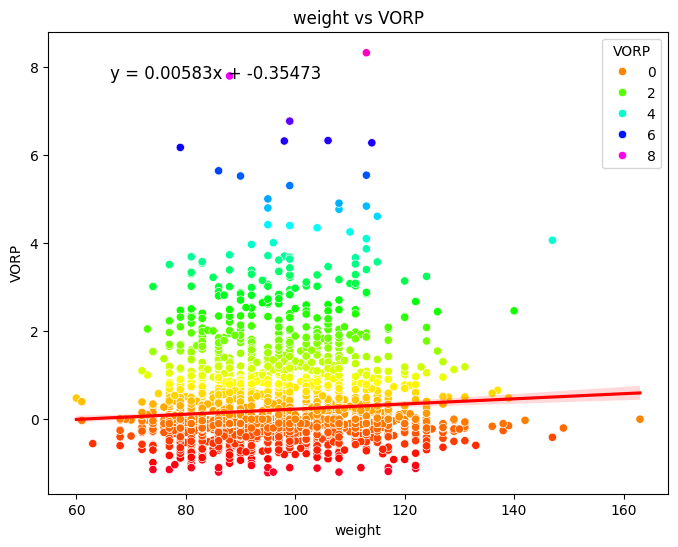

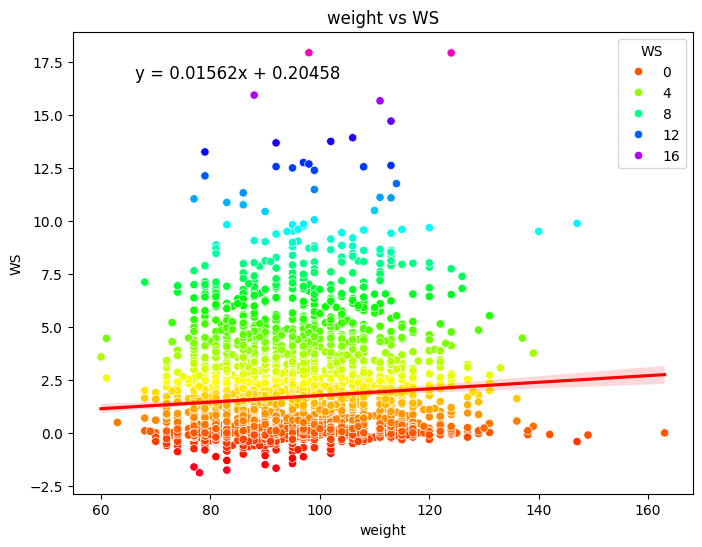

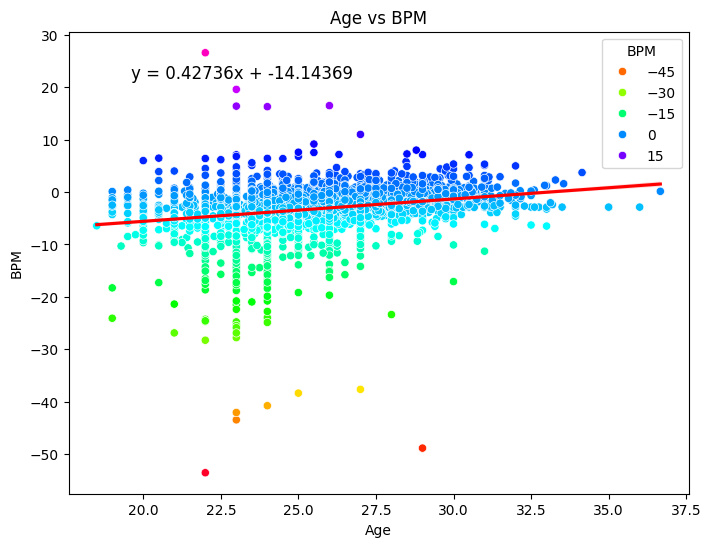

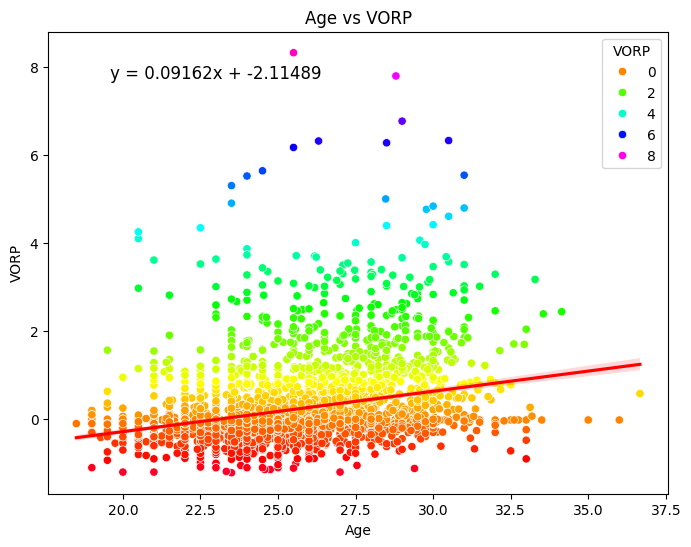

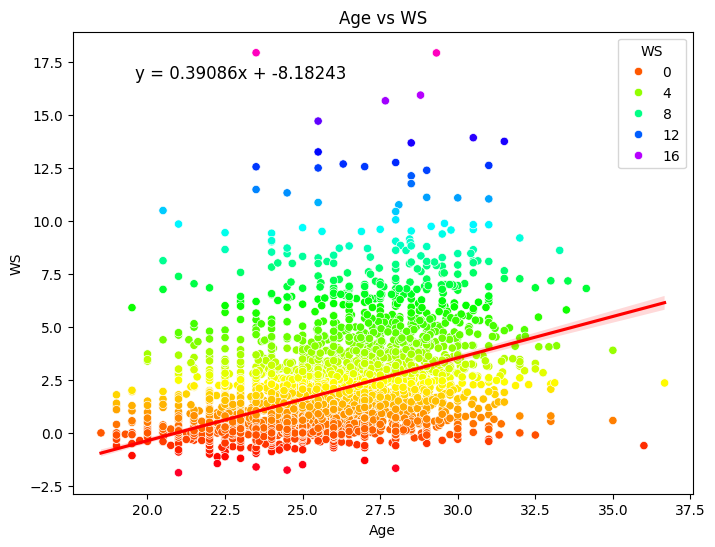

In [81]:
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Columns of interest
xVars = ['height', 'weight', 'Age']
yVars = ['BPM', 'VORP', 'WS']

# Check for missing values
missingVals = playerData[xVars + yVars].isnull().sum()
missingPct = (missingVals / len(playerData)) * 100

print("Missing Values:\n", missingVals)
print("\nMissing Value Percentage:\n", missingPct)

# Convert data types if needed (Handle potential errors gracefully)
for col in xVars + yVars:
    playerData[col] = pd.to_numeric(playerData[col], errors='raise')

# Descriptive statistics and distributions
descStats = playerData[xVars + yVars].describe()
print("\nDescriptive Statistics:\n", descStats)

# Re-visualize distributions
plt.figure(figsize=(15, 10))
colors = list(mcolors.TABLEAU_COLORS)  # Get a list of distinct colors
num_colors = len(colors)
for i, col in enumerate(['height', 'weight', 'Age', 'BPM', 'VORP', 'WS']):
    plt.subplot(2, 3, i + 1)
    # Histogram with distinct colors
    n, bins, patches = plt.hist(playerData[col], bins='auto')
    # Apply colors to the bars, cycling through the color list
    for j, patch in enumerate(patches):
        patch.set_facecolor(colors[j % num_colors])
    # Overlay KDE plot
    sns.kdeplot(playerData[col], color='black')  # Black KDE line for contrast
    plt.title(f'Distribution of {col} after cleaning')
plt.tight_layout()
plt.show()


# Correlation analysis
corrMatrix = playerData[xVars + yVars].corr()
print("\nCorrelation Matrix:\n", corrMatrix)

plt.figure(figsize=(10, 7.5))
sns.heatmap(corrMatrix, annot=True, cmap='rainbow')
plt.title('Correlation Heatmap')
plt.show()

strongestPosCor = corrMatrix.unstack().sort_values(ascending=False).drop_duplicates().head(1)
strongestNegCor = corrMatrix.unstack().sort_values(ascending=True).drop_duplicates().head(1)

print(f"\nStrongest positive correlation: {strongestPosCor}")
print(f"\nStrongest negative correlation: {strongestNegCor}")

# Summarize findings
print("\nSummary:")
print(f"  Missing values: {missingVals}")
print(f"  Strongest positive correlation: {strongestPosCor}")
print(f"  Strongest negative correlation: {strongestNegCor}")

for xVar in xVars:
    for yVar in yVars:
        plt.figure(figsize=(8, 6))  # Adjust figure size as needed
        # Use scatterplot for hue and then overlay regplot
        sns.scatterplot(x=playerData[xVar], y=playerData[yVar], hue=playerData[yVar], palette="gist_rainbow")
        sns.regplot(x=playerData[xVar], y=playerData[yVar], scatter=False, color='red')

        # Get regression coefficients
        slope, intercept = np.polyfit(playerData[xVar], playerData[yVar], 1)

        # Create equation string
        equation = f'y = {slope:.5f}x + {intercept:.5f}'

        # Add equation to plot
        plt.text(0.1, 0.9, equation, transform=plt.gca().transAxes, fontsize=12)
        plt.title(f'{xVar} vs {yVar}')
        plt.xlabel(xVar)
        plt.ylabel(yVar)
        plt.show()

## Data cleaning

### Subtask:
Clean the data by handling missing values and inconsistencies.


**Reasoning**:
Impute missing values in specified columns using the median, convert specified columns to numeric types, handle duplicates, and re-examine descriptive statistics and distributions.




Dropped 0 duplicate rows.

Descriptive Statistics after cleaning:
             height       weight          Age          BPM         VORP  \
count  3921.000000  3921.000000  3921.000000  3921.000000  3921.000000   
mean    198.704922    94.783219    25.246367    -3.354373     0.198280   
std       9.269761    12.039515     2.629688     4.081125     0.809884   
min     160.000000    60.000000    18.500000   -53.600000    -1.214570   
25%     190.000000    86.000000    23.000000    -4.376560    -0.132487   
50%     198.000000    95.000000    25.000000    -2.879878    -0.017647   
75%     206.000000   102.000000    27.000000    -1.686775     0.154678   
max     231.000000   163.000000    36.666667    26.600000     8.315174   

                WS  
count  3921.000000  
mean      1.685295  
std       2.239766  
min      -1.880328  
25%       0.050000  
50%       0.862052  
75%       2.655773  
max      17.950769  


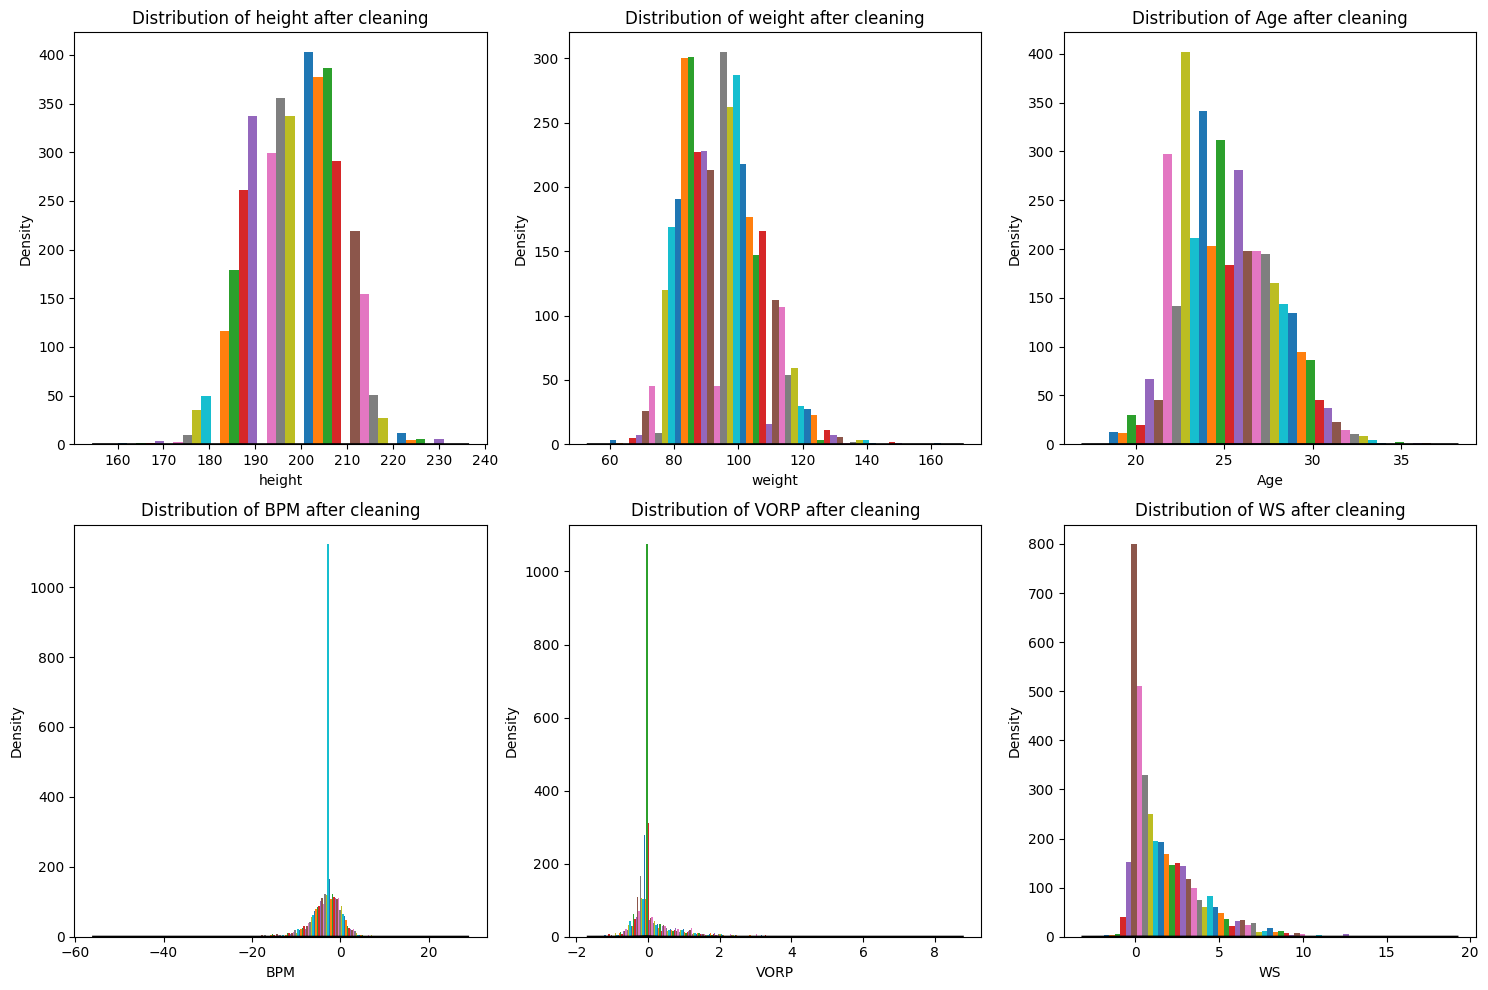


Correlation Matrix after cleaning:
           height    weight       Age       BPM      VORP        WS
height  1.000000  0.825630 -0.015828  0.004132  0.102916  0.088543
weight  0.825630  1.000000 -0.010623  0.010416  0.086733  0.083974
Age    -0.015828 -0.010623  1.000000  0.275372  0.297502  0.458902
BPM     0.004132  0.010416  0.275372  1.000000  0.512709  0.501665
VORP    0.102916  0.086733  0.297502  0.512709  1.000000  0.741026
WS      0.088543  0.083974  0.458902  0.501665  0.741026  1.000000


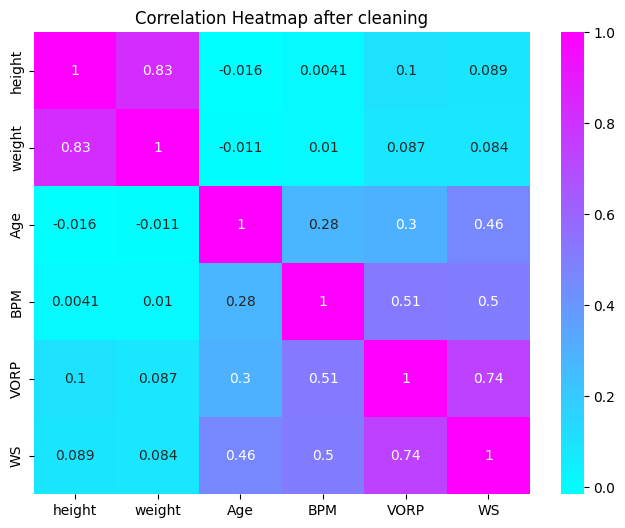

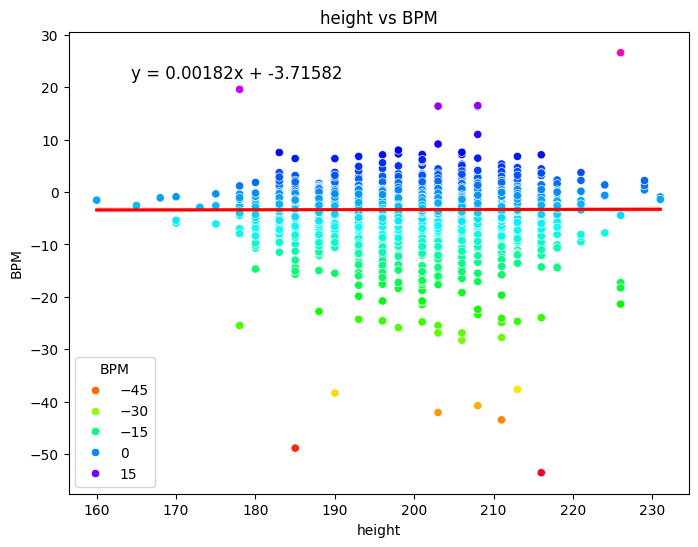

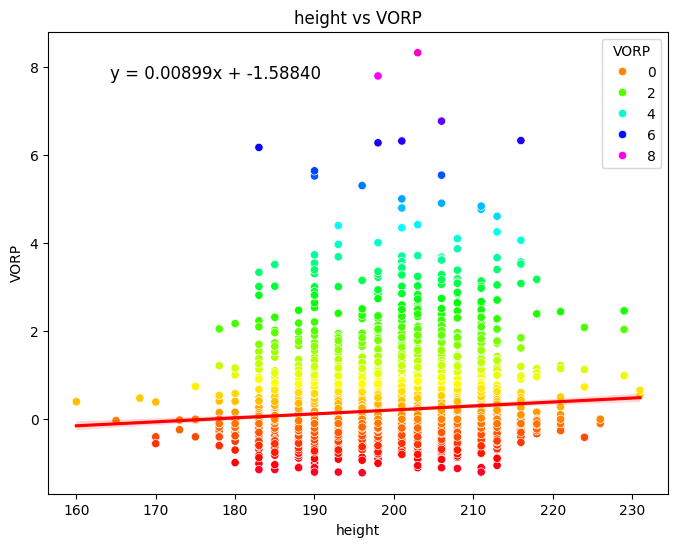

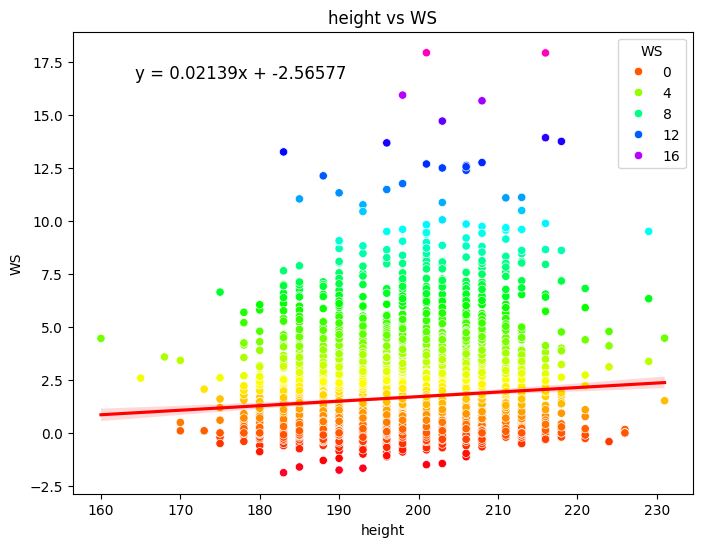

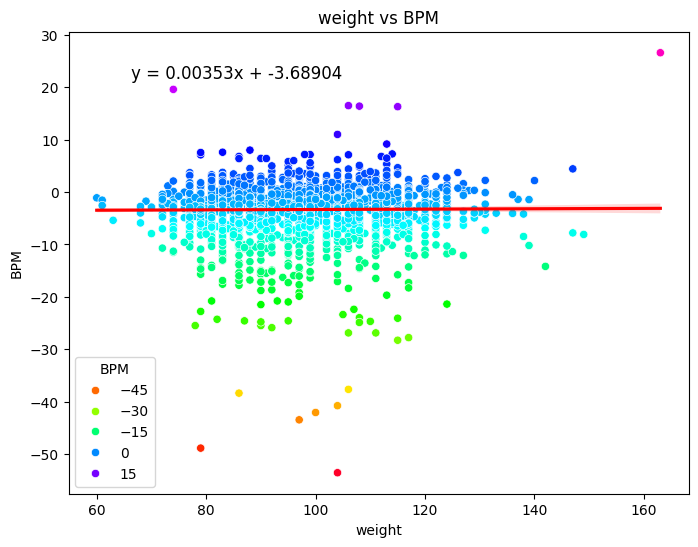

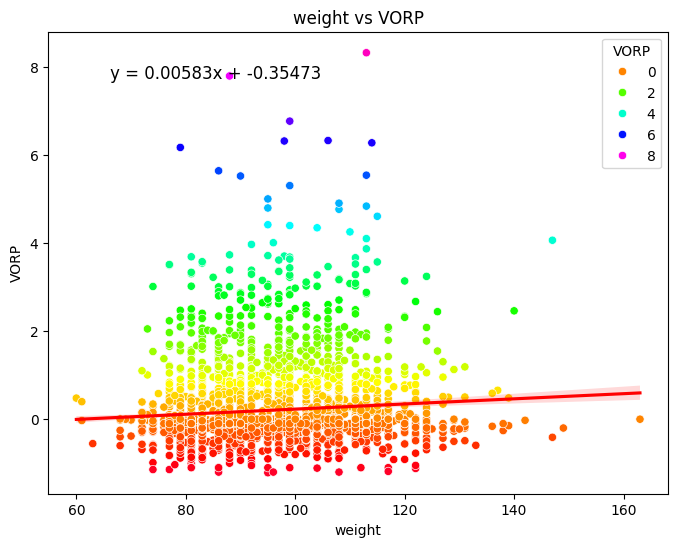

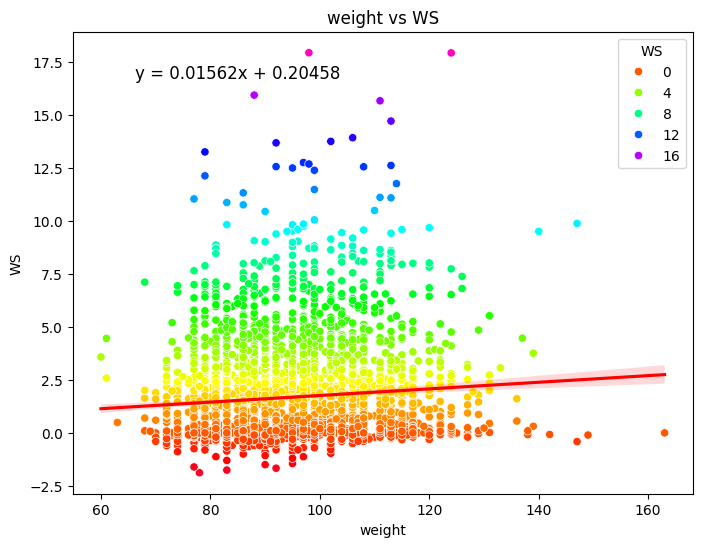

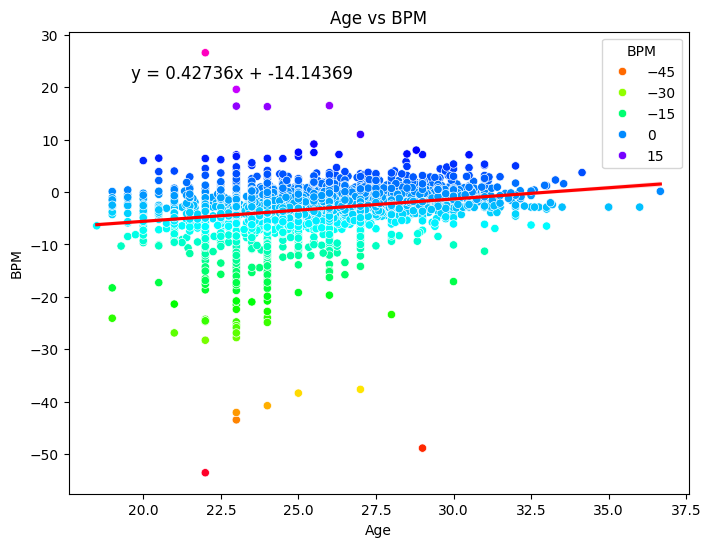

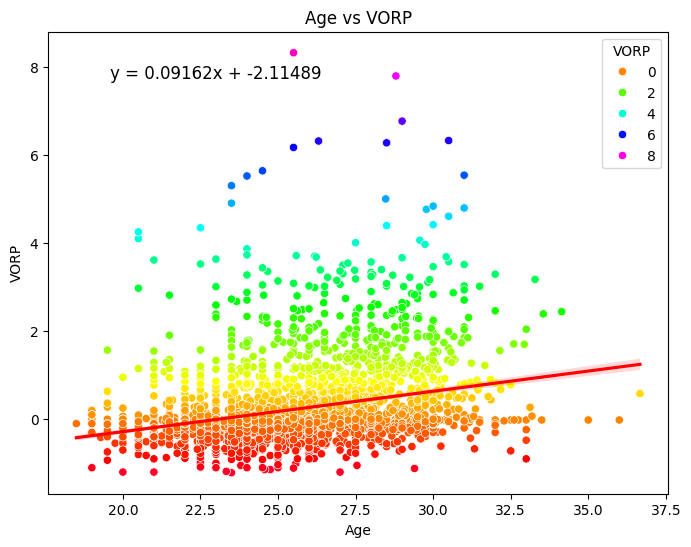

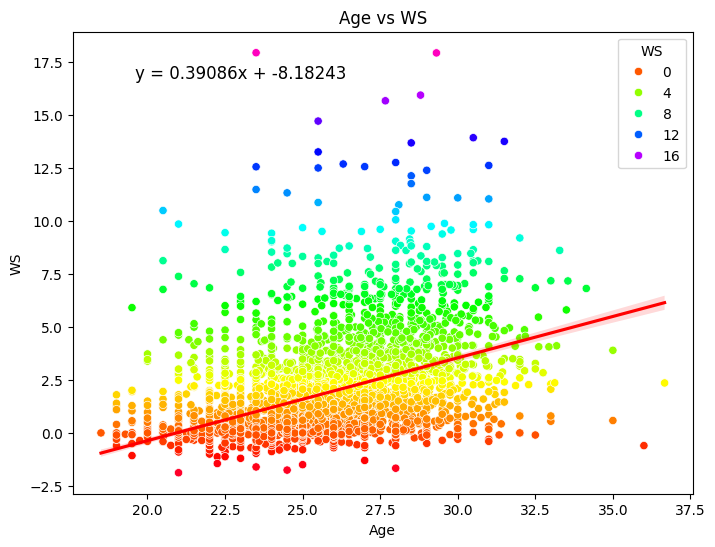

In [83]:
# Data cleaning
# Impute missing values using the median
for col in ['Age', 'BPM', 'VORP', 'WS']:
    playerData[col] = playerData[col].fillna(playerData[col].median())

# Convert specified columns to numeric, handling errors
for col in ['height', 'weight', 'Age', 'BPM', 'VORP', 'WS']:
    playerData[col] = pd.to_numeric(playerData[col], errors='raise')

# Handle duplicate rows (dropping duplicates and keeping the first occurrence)
initial_rows = len(playerData)
playerData = playerData.drop_duplicates()
dropped_rows = initial_rows - len(playerData)
print(f"\nDropped {dropped_rows} duplicate rows.")

# Re-examine descriptive statistics
descStats = playerData[['height', 'weight', 'Age', 'BPM', 'VORP', 'WS']].describe()
print("\nDescriptive Statistics after cleaning:\n", descStats)

# Re-visualize distributions
plt.figure(figsize=(15, 10))
colors = list(mcolors.TABLEAU_COLORS)  # Get a list of distinct colors
num_colors = len(colors)
for i, col in enumerate(['height', 'weight', 'Age', 'BPM', 'VORP', 'WS']):
    plt.subplot(2, 3, i + 1)
    # Histogram with distinct colors
    n, bins, patches = plt.hist(playerData[col], bins='auto')
    # Apply colors to the bars, cycling through the color list
    for j, patch in enumerate(patches):
        patch.set_facecolor(colors[j % num_colors])
    # Overlay KDE plot
    sns.kdeplot(playerData[col], color='black')  # Black KDE line for contrast
    plt.title(f'Distribution of {col} after cleaning')
plt.tight_layout()
plt.show()

# Correlation analysis after cleaning
corrMatrix = playerData[['height', 'weight', 'Age', 'BPM', 'VORP', 'WS']].corr()
print("\nCorrelation Matrix after cleaning:\n", corrMatrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corrMatrix, annot=True, cmap='cool')
plt.title('Correlation Heatmap after cleaning')
plt.show()

for xVar in xVars:
    for yVar in yVars:
        plt.figure(figsize=(8, 6))  # Adjust figure size as needed
        # Use scatterplot for hue and then overlay regplot
        sns.scatterplot(x=playerData[xVar], y=playerData[yVar], hue=playerData[yVar], palette="gist_rainbow")
        sns.regplot(x=playerData[xVar], y=playerData[yVar], scatter=False, color='red')

        # Get regression coefficients
        slope, intercept = np.polyfit(playerData[xVar], playerData[yVar], 1)

        # Create equation string
        equation = f'y = {slope:.5f}x + {intercept:.5f}'

        # Add equation to plot
        plt.text(0.1, 0.9, equation, transform=plt.gca().transAxes, fontsize=12)
        plt.title(f'{xVar} vs {yVar}')
        plt.xlabel(xVar)
        plt.ylabel(yVar)
        plt.show()

## Feature engineering

### Subtask:
Engineer new features from the existing data, focusing on improving the predictive power of the models.


**Reasoning**:
Calculate BMI, bin age, and optionally scale features.

